# はじめに

このノートでは、PyTorch Geometricを利用してグラフニューラルネットワークを構築することを目指す。最初はPyTorchの基礎からはじめ、グラフニューラルネットワーク、PyTorch Geometricと内容を進めていく。

今回は、PyTorch Geometricのイントロダクションで紹介されている下記のハンズオンを実行して理解を深める。

- [2. Node Classification.ipynb - Colab](https://colab.research.google.com/drive/14OvFnAXggxB8vM4e8vSURUp1TaKnovzX?usp=sharing#scrollTo=dszt2RUHE7lW)

下記はグラフニューラルネットワークを理解するための参考サイト。

- [グラフニューラルネットワーク | 佐藤 竜馬](https://www.amazon.co.jp/%E3%82%B0%E3%83%A9%E3%83%95%E3%83%8B%E3%83%A5%E3%83%BC%E3%83%A9%E3%83%AB%E3%83%8D%E3%83%83%E3%83%88%E3%83%AF%E3%83%BC%E3%82%AF-%E6%A9%9F%E6%A2%B0%E5%AD%A6%E7%BF%92%E3%83%97%E3%83%AD%E3%83%95%E3%82%A7%E3%83%83%E3%82%B7%E3%83%A7%E3%83%8A%E3%83%AB%E3%82%B7%E3%83%AA%E3%83%BC%E3%82%BA-%E4%BD%90%E8%97%A4-%E7%AB%9C%E9%A6%AC/dp/4065347823)
- [グラフ深層学習のすゝめ。 - YouTube](https://www.youtube.com/watch?v=7rgXi3Xp6NI)
- [GCN — グラフ道場](https://yuya-s.github.io/GraphDojo/01GCN.html)
- [Tutorial 6: Basics of Graph Neural Networks](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/06-graph-neural-networks.html)
- [Static and Dynamic Attention: Implications for Graph Neural Networks](https://medium.com/data-science/static-and-dynamic-attention-implications-for-graph-neural-networks-eda0d9d7b60a)
- [CS224W | Home](https://web.stanford.edu/class/cs224w/index.html)
- [nn.labml.ai/ja/graphs](https://nn.labml.ai/#:~:text=%E2%9C%A8%20Graph%20Neural%20Networks)

ここまではノードのことを頂点と表現していたが、以降はノードと記載する。

## ノード分類

グラフニューラルネットワークはノード分類、グラフ分類などを行うことができる。今回は、ノードの分類を行う。使用するサンプルデータは、論文の引用ネットワークのデータセット`Cora`を使用する。`Cora`データセットは1つのグラフ、1433の特徴量、7つのクラスから構成される。

In [1]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

dataset = Planetoid(root="data/Planetoid", name="Cora", transform=NormalizeFeatures())

print()
print(f"Dataset: {dataset}:")
print("======================")
print(f"Number of graphs: {len(dataset)}")
print(f"Number of features: {dataset.num_features}")
print(f"Number of classes: {dataset.num_classes}")
print(f"class: {dataset.y.unique()}")

data = dataset[0]  # Get the first graph object.

print()
print(data)
print(
    "==========================================================================================================="
)


Dataset: Cora():
Number of graphs: 1
Number of features: 1433
Number of classes: 7
class: tensor([0, 1, 2, 3, 4, 5, 6])

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


ノード数は2708、エッジ数は10556、ノードの平均次数は3.9、訓練ノード数は140、訓練ノードのラベル率は0.05、孤立ノードはFalse、自己ループはFalse、有向グラフはTrueとのこと。訓練ノードは140ノード、検証ノードは500ノード、テストノードは1000ノードとのこと。
これにより、トレーニングノードのラベル率はわずか 5% になります。

In [2]:
# Gather some statistics about the graph.
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Average node degree: {data.num_edges / data.num_nodes:.2f}")
print(f"Number of training nodes: {data.train_mask.sum()}")
print(f"Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}")
print(f"Number of validating nodes: {data.val_mask.sum()}")
print(f"Validation node label rate: {int(data.val_mask.sum()) / data.num_nodes:.2f}")
print(f"Number of testing nodes: {data.test_mask.sum()}")
print(f"Test node label rate: {int(data.test_mask.sum()) / data.num_nodes:.2f}")
print(f"Has isolated nodes: {data.has_isolated_nodes()}")
print(f"Has self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")

Number of nodes: 2708
Number of edges: 10556
Average node degree: 3.90
Number of training nodes: 140
Training node label rate: 0.05
Number of validating nodes: 500
Validation node label rate: 0.18
Number of testing nodes: 1000
Test node label rate: 0.37
Has isolated nodes: False
Has self-loops: False
Is undirected: True


ノード数は2708、検証ノード、テストノードを含めたノード数は1500なので、訓練ノードは1208ノード使えそうではあるが、ここでは訓練ノードは140ノードである。これは`Cora`データセットがラベルがほとんど無い状況で、グラフ構造を活かして学習できるか？というテーマを検証するためのデータセットであり、分析内容であるため。

`transform=NormalizeFeatures()` で[データ変換]を利用する。データ変換は、入力データをニューラルネットワークに入力する前に、正規化、データ拡張などのために使用される。ここでは、入力特徴ベクトルをbag-of-wordsで表現しておく。

## ニューラルネットワーク


まずはグラフ構造を無視して、Bag-of-Wordsの特徴表現のみで文書のカテゴリを推測するニューラルネットワークを構築する。1433次元の特徴ベクトルを低次元埋め込み（`hidden_​​channels=16`）に縮小し、2番目の線形層は各低次元ノード埋め込みを7つのクラスのいずれかにマッピングする分類器として機能させる。

In [3]:
import torch
from torch.nn import Linear
import torch.nn.functional as F


class MLP(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(12345)
        self.lin1 = Linear(dataset.num_features, hidden_channels)  # (1433 × 16)
        self.lin2 = Linear(hidden_channels, dataset.num_classes)  # (  16 ×  7)

    def forward(self, x):
        x = self.lin1(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        return x


model = MLP(hidden_channels=16)
print(model)

MLP(
  (lin1): Linear(in_features=1433, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=7, bias=True)
)


In [4]:
model = MLP(hidden_channels=16)
criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion.
optimizer = torch.optim.Adam(
    model.parameters(), lr=0.01, weight_decay=5e-4
)  # Define optimizer.


def train():
    # 訓練モード
    model.train()
    # 勾配の初期化
    optimizer.zero_grad()
    # フォーワードプロパゲーション
    out = model(data.x)  # Perform a single forward pass.
    # クロスエントロピーで損失計算。使用するデータは学習ノードのみ
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    # バックプロパゲーション
    loss.backward()
    # 勾配をもとにパラメタを更新
    optimizer.step()
    return loss


def test():
    # 評価モード
    model.eval()
    # フォーワードプロパゲーション
    out = model(data.x)
    # 最大確率のクラスを予測
    pred = out.argmax(dim=1)
    # 正解と予測を比較
    test_correct = pred[data.test_mask] == data.y[data.test_mask]
    # 正解率を計算
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
    return test_acc

In [5]:
for epoch in range(1, 201):
    loss = train()
    if epoch % 10 == 0:
        print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}")

Epoch: 010, Loss: 1.8849
Epoch: 020, Loss: 1.7383
Epoch: 030, Loss: 1.5396
Epoch: 040, Loss: 1.3391
Epoch: 050, Loss: 1.1060
Epoch: 060, Loss: 0.9173
Epoch: 070, Loss: 0.7889
Epoch: 080, Loss: 0.6899
Epoch: 090, Loss: 0.6685
Epoch: 100, Loss: 0.6106
Epoch: 110, Loss: 0.5888
Epoch: 120, Loss: 0.5277
Epoch: 130, Loss: 0.5053
Epoch: 140, Loss: 0.5623
Epoch: 150, Loss: 0.4934
Epoch: 160, Loss: 0.4170
Epoch: 170, Loss: 0.4678
Epoch: 180, Loss: 0.4808
Epoch: 190, Loss: 0.4602
Epoch: 200, Loss: 0.4827


モデルをトレーニングした後、`test` 関数で未知のラベルに対してどの程機能するかを確認する。ここでは、モデルの精度、つまり正しく分類されたノードの比率に注目する。

In [6]:
test_acc = test()
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.5740


ニューラルネットワークのパフォーマンスのテスト精度は60%にいかないくらい。主な理由は、このモデルはトレーニングノードの数が少ないため、過学習に陥りやすく、未知のノード表現への一般化が不十分なため。意図的に学習データを工夫して、ニューラルネットワークとグラフニューラルネットワークの違いを明確にする。

## グラフニューラルネットワーク

先ほどと同じ問題をグラフニューラルネットワークで対処する。レイヤーは畳み込み層を2つ使用する。

In [7]:
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GCNConv(dataset.num_features, hidden_channels)  # (1433 × 16)
        self.conv2 = GCNConv(hidden_channels, dataset.num_classes)  # (  16 ×  7)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x


model = GCN(hidden_channels=32)
print(model)

GCN(
  (conv1): GCNConv(1433, 32)
  (conv2): GCNConv(32, 7)
)


学習前の状態でGCNのノード埋め込みを視覚化しておく。

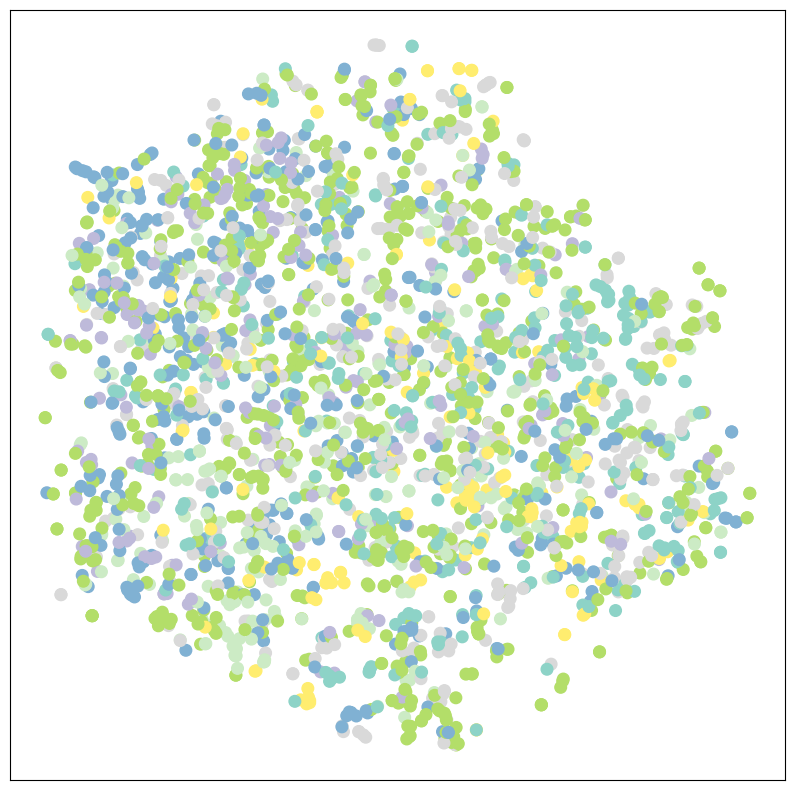

In [8]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10, 10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set3")
    plt.show()


out = model(data.x, data.edge_index)
visualize(out, color=data.y)

GNNに置き換えるだけで、80%を超える性能を達成できる。MLPで得られた役60%のテスト精度とは対照的であり、グラフの隣接情報がより良いパフォーマンスを得る上で重要な役割を果たしていることを示す。

In [9]:
model = GCN(hidden_channels=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()


def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(
        out[data.train_mask], data.y[data.train_mask]
    )  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss


def test():
    model.eval()
    out = model(data.x, data.edge_index)
    print("out==========================\n", out)
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    print("pred==========================\n", pred)
    print("==============================")
    test_correct = (
        pred[data.test_mask] == data.y[data.test_mask]
    )  # Check against ground-truth labels.
    test_acc = int(test_correct.sum()) / int(
        data.test_mask.sum()
    )  # Derive ratio of correct predictions.
    return test_acc


for epoch in range(1, 1001):
    loss = train()
    if epoch % 100 == 0:
        print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}")

test_acc = test()
print(f"Test Accuracy: {test_acc:.4f}")

Epoch: 100, Loss: 0.6375
Epoch: 200, Loss: 0.3751
Epoch: 300, Loss: 0.2826
Epoch: 400, Loss: 0.2411
Epoch: 500, Loss: 0.2363
Epoch: 600, Loss: 0.1707
Epoch: 700, Loss: 0.1825
Epoch: 800, Loss: 0.1846
Epoch: 900, Loss: 0.1965
Epoch: 1000, Loss: 0.2290
out==========================
 tensor([[-0.7038, -0.4242, -0.6167,  ...,  0.1587, -1.3786, -1.4512],
        [ 0.4104, -0.7904, -1.5711,  ...,  5.0116, -1.5751, -1.5610],
        [ 0.1901, -0.4701, -1.4143,  ...,  3.8314, -1.6276, -1.7778],
        ...,
        [ 1.9869,  2.1891, -3.0092,  ..., -2.4187,  1.0134, -0.5428],
        [-0.6179, -0.0443, -0.3433,  ...,  0.8853, -1.4573, -2.0662],
        [-0.6494, -0.0411, -0.1995,  ...,  0.6581, -1.2083, -1.9484]],
       grad_fn=<AddBackward0>)
pred==========================
 tensor([3, 4, 4,  ..., 1, 3, 3])
Test Accuracy: 0.8120


学習済みモデルの埋め込みを見ることで、精度を可視化して確認できる。同じカテゴリのノードのクラスタリングが改善されている。

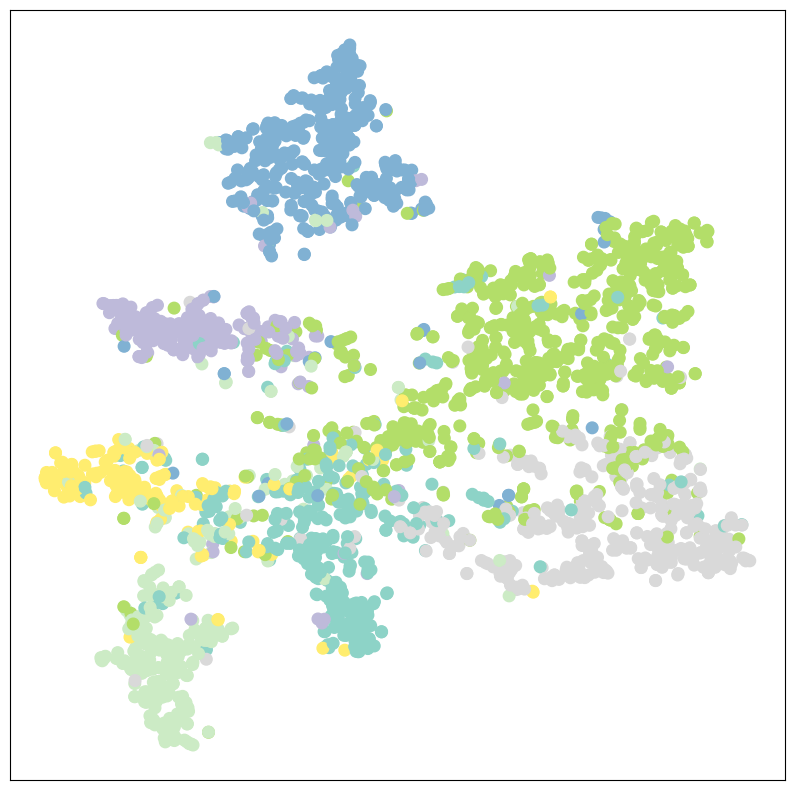

In [10]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)

ハンズオンに記載されている演習にも取り組んでおく。

- 過学習を回避するために、`Cora` データセットの`data.val_mask`という検証ノードセットを利用して学習を行うこと
- 隠れ特徴の次元数または層数を増やした場合、`GCN` はどのように動作しますか？層数を増やすことは役立ちますか？
- 異なる GNN 層を使用して、モデル性能がどのように変化するかを確認

`GATConv()`を利用する。引数は入力される特徴量の数`in_channels`、その層から出てくるデータの次元数`out_channels`。`heads`はマルチヘッドアテンションのことで、同時に学習したいアテンションの数を指定する。感覚的には1つのアテンション（シングルヘッド）だけだと、モデルは一番目立つ特徴だけに引きずられることもあるので、増やすことで様々な観点を考慮したアテンションを作るようなイメージ。そして、`concat=True`とすることで、異なる視点のアテンションを1つに連結する。`concat=False`とすると、マルチヘッドアテンションの結果を平均する。


In [11]:
from torch_geometric.nn import GATConv


class GAT(torch.nn.Module):
    def __init__(self, hidden_channels, heads):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GATConv(
            in_channels=dataset.num_features,  # 1433
            out_channels=hidden_channels,  # 8
            heads=heads,  # 8
            concat=True,  # True
            dropout=0.6,  # 0.6
        )
        self.conv2 = GATConv(
            in_channels=hidden_channels * heads,  # 8 * 8 = 64
            out_channels=dataset.num_classes,  # 7
            heads=1,  # 1
            concat=False,  # False
            dropout=0.6,  # 0.6
        )

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return x


model = GAT(hidden_channels=8, heads=8)
print(model)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

GAT(
  (conv1): GATConv(1433, 8, heads=8)
  (conv2): GATConv(64, 7, heads=1)
)


モデルの部分で気になるのは`out = model(data.x, data.edge_index)`の部分。素直に見ると、モデルにデータ全部を渡している。学習データのみにするほうが望ましくみえるが、これはTransductive Learning（トランスダクティブ学習）と呼ばれる手法らしい。

学習時にテストデータの入力構造を既に知っている設定、ただし、テストラベルは使わない、という学習方法。`Cora`の場合、ノード2708は最初から全部見えている、エッジ構造も全部見えている、特徴量も全部見えている。しかしラベルは140ノードだけ。test ラベルは使っていないので、リークにはならない。

グラフニューラルネットワークでは、「ノード同士のつながり」が何より重要なので、グラフニューラルネットワークでよく利用されるとのこと。SNSの友だち関係で考えると、ユーザーA（訓練データ）、ユーザーB（テストデータ）、AとBはエッジでつながっている。

もし、学習時にB（テストデータ）を隠してしまうと、AとBをつなぐエッジも消えてしまう。すると、Aと繋がっているのは誰か？という重要な情報が失われ、Aの学習精度まで落ちる。GNNでは「Bが誰かは言わないけど、そこにBがいて、Aとつながっていることだけは教える」というTransductiveな手法がよく使われるらしい

In [12]:
def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(
        out[data.train_mask], data.y[data.train_mask]
    )  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss


def test(mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    correct = pred[mask] == data.y[mask]  # Check against ground-truth labels.
    acc = int(correct.sum()) / int(mask.sum())  # Derive ratio of correct predictions.
    return acc

あとは学習データを使って学習を進めながら、検証データで性能を確認して、ベストモデルを選択する。ベストモデルが選択されたら、テストデータで性能を確認する。

In [13]:
import copy

best_val_acc = 0
best_test_acc = 0
best_model_state = None

for epoch in range(1, 1001):

    loss = train()
    val_acc = test(data.val_mask)
    # --- モデル選択 ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())

    if epoch % 100 == 0:
        print(f"Epoch: {epoch:03d}, " f"Loss: {loss:.4f}, " f"Val: {val_acc:.4f}, ")

# --- ベストモデルを復元 ---
model.load_state_dict(best_model_state)

test_acc = test(data.test_mask)

print("\n==============================")
print(f"Best Val Acc: {best_val_acc:.4f}")
print(f"Test Acc (Best Model): {test_acc:.4f}")
print("==============================")

Epoch: 100, Loss: 0.9888, Val: 0.8220, 
Epoch: 200, Loss: 0.7342, Val: 0.8040, 
Epoch: 300, Loss: 0.7112, Val: 0.7980, 
Epoch: 400, Loss: 0.6317, Val: 0.7920, 
Epoch: 500, Loss: 0.6361, Val: 0.8000, 
Epoch: 600, Loss: 0.5565, Val: 0.7920, 
Epoch: 700, Loss: 0.5032, Val: 0.7900, 
Epoch: 800, Loss: 0.5712, Val: 0.7920, 
Epoch: 900, Loss: 0.6007, Val: 0.7900, 
Epoch: 1000, Loss: 0.5319, Val: 0.8020, 

Best Val Acc: 0.8260
Test Acc (Best Model): 0.8280
